# Bering Sea: ocean, sea ice and waves — workshop diagnostics

A guided look at a coupled **MOM6 + CICE + WW3** regional run of the Bering Sea, aimed at someone
who knows ocean models but not sea ice or waves.

Everything is daily-mean output from the case you built! CICE daily fields carry a
`_d` suffix (`aice_d`, `hi_d`, ...) because they come from CICE history **stream 2**.

### The physical story this run is built to show

Waves radiate into the ice edge and **fracture large floes into smaller ones**. Smaller floes have
more edge per unit area, and ice melts laterally from its edges — so a broken-up ice cover melts
faster than a solid one. Faster melt opens more water, longer open-water fetch builds bigger waves,
which break more ice. That feedback is the **marginal ice zone (MIZ)**, and representing it is the
entire reason a model carries a *floe size distribution* (FSD) instead of just ice concentration.

### Two caveats, stated up front

1. **No WW3 boundary spectra.** This configuration has no wave forcing at the open boundaries, so
   waves are generated *only* by winds inside the domain. Real swell travels hundreds of km into
   pack ice and is absent here. Wave heights, and therefore fracturing, are underestimates.
2. **327 cells carry a garbage wave height** (~2.5e15 m). It is the same 327 cells every day — a
   static artifact where the WW3 and CICE masks disagree, not evolving physics. The other 8733 wet
   cells are a sensible 0-9 m. `WAVE_MAX` below masks them; do not remove that mask without
   checking.

In [1]:
import os
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib import animation
from IPython.display import HTML

CASE = "koztebue_ocn_wav_ice.001"
# CESM's default short-term archive on Derecho (DOUT_S_ROOT). $SCRATCH points at your Derecho
# scratch from both Derecho and Casper. If you changed DOUT_S_ROOT, point ARCHIVE there instead.
ARCHIVE = Path(os.environ["SCRATCH"]) / "archive" / CASE

ICE_EDGE = 0.15   # conventional ice-edge concentration
WAVE_MAX = 100.0  # m -- above this is the mask artifact described above

ice = xr.open_mfdataset(sorted((ARCHIVE/"ice"/"hist").glob(f"{CASE}.cice.h1.*.nc")),
                        combine="by_coords", decode_times=True)
ocn = xr.open_mfdataset(sorted((ARCHIVE/"ocn"/"hist").glob(f"{CASE}.mom6.h.sfc.*.nc")),
                        combine="by_coords", decode_times=True)

LON, LAT = ice["TLON"].values, ice["TLAT"].values          # 2-D, (nj, ni)
NDAYS = ice.sizes["time"]

# The case runs on a NO_LEAP calendar, so xarray decodes time to cftime objects, which matplotlib
# will not plot directly. Plot against a day index and label the ticks with date strings.
DAYS = np.arange(NDAYS)
DATES = [str(t)[:10] for t in ice.time.values]


def datelabels(ax, every=None):
    every = every or max(1, NDAYS // 8)
    ax.set_xticks(DAYS[::every])
    ax.set_xticklabels(DATES[::every], rotation=45, ha="right", fontsize=8)


print(f"{NDAYS} daily frames | ice {dict(ice.sizes)}")
print("ocean sfc vars:", [v for v in ("tos", "sos", "mlotst", "SSU", "SSV") if v in ocn])

31 daily frames | ice {'time': 31, 'nbnd': 2, 'nkice': 8, 'nksnow': 3, 'nkbio': 5, 'nkaer': 7, 'nj': 125, 'ni': 300, 'nvertices': 4, 'nc': 5, 'nf': 12}
ocean sfc vars: ['tos', 'sos', 'mlotst', 'SSU', 'SSV']


## 1. The setting: SST and where the ice is

Ocean and ice are on the same horizontal grid here, so they can be drawn together directly. The
black contour is the **ice edge**, conventionally the 15% concentration line.

Note the ice sits where SST is at the freezing point (about -1.8 C for seawater) — ice and SST are
not independent fields, they are two views of the same surface heat budget.

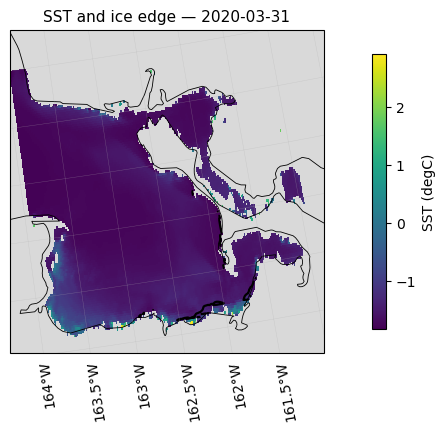

In [2]:
PROJ = ccrs.Stereographic(central_latitude=65.0, central_longitude=187.5)
XT = ccrs.PlateCarree()      # data is in plain lon/lat (0-360)


def basemap(ax, title=""):
    ax.set_extent([LON.min(), LON.max(), LAT.min(), LAT.max()], XT)
    ax.coastlines("10m", linewidth=0.6)
    ax.set_facecolor("0.85")
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    ax.set_title(title, fontsize=11)


day = -1                                        # last day
sst = ocn["tos"].isel(time=day).values
aice = ice["aice_d"].isel(time=day).values

fig, ax = plt.subplots(figsize=(11, 4.2), subplot_kw={"projection": PROJ}, constrained_layout=True)
basemap(ax, f"SST and ice edge — {str(ice.time.values[day])[:10]}")
pc = ax.pcolormesh(LON, LAT, sst, cmap="viridis", shading="nearest", transform=XT)
ax.contour(LON, LAT, aice, levels=[ICE_EDGE], colors="k", linewidths=1.6, transform=XT)
fig.colorbar(pc, ax=ax, label="SST (degC)", shrink=0.85)
plt.show()

## 2. The movie: SST with ice concentration on top

Ice concentration is drawn as a translucent white overlay, so you see the ocean underneath and the
ice pack riding on it. Watch the ice edge advance and flex with the weather.

With only a month of output this is short. The same cell will produce a full seasonal animation once
the 12-month case finishes — nothing here depends on the run length.

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.2), subplot_kw={"projection": PROJ},
                       constrained_layout=True)
basemap(ax)

vmin, vmax = np.nanpercentile(ocn["tos"].values, [1, 99])
sst_norm = plt.Normalize(vmin, vmax)
sst_cmap = plt.get_cmap("viridis")
ice_cmap = plt.get_cmap("Blues_r")
ICE_ALPHA = 0.75

# Two separate alpha-blended pcolormesh layers leave hairline white seams at every
# cell edge (an Agg antialiasing artifact when adjacent quads are only partially
# opaque) -- not fixed by antialiased=False, edgecolors, or gouraud shading. The
# fix is to pre-composite SST and ice into a single fully-opaque RGBA image and
# draw that as one mesh, so there is no partial-alpha quad-on-quad blending left
# for the renderer to seam.
def composite(t):
    sst = ocn["tos"].isel(time=t).values
    a   = ice["aice_d"].isel(time=t).values
    sst_rgb = sst_cmap(sst_norm(sst))[..., :3]
    ice_rgb = ice_cmap(plt.Normalize(0, 1)(np.clip(a, 0, 1)))[..., :3]
    ice_a   = np.where(a >= 0.05, ICE_ALPHA, 0.0)
    rgb   = ice_rgb * ice_a[..., None] + sst_rgb * (1 - ice_a[..., None])
    alpha = np.where(np.isnan(sst), 0.0, 1.0)       # land/missing -> transparent
    return np.dstack([rgb, alpha])

pc = ax.pcolormesh(LON, LAT, composite(0), shading="nearest", transform=XT)
sm = plt.cm.ScalarMappable(norm=sst_norm, cmap=sst_cmap)     # for the colorbar only
fig.colorbar(sm, ax=ax, label="SST (degC)", shrink=0.85)

def frame(t):
    pc.set_array(composite(t))
    ax.set_title(f"SST + sea ice concentration — {str(ice.time.values[t])[:10]}", fontsize=11)
    return (pc,)

anim = animation.FuncAnimation(fig, frame, frames=NDAYS, interval=400, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

In [28]:
OUT = Path.cwd() / "bering_sst_ice_animation.mp4"
anim.save(OUT, writer=animation.FFMpegWriter(fps=1000/400, bitrate=1800))
print(f"saved {OUT}")

saved /glade/work/skygale/crocodile2026/workspace/bering_sst_ice_animation.mp4


## 3. The wave field inside the ice

`wave_sig_ht_d` is significant wave height where there is ice — the quantity that drives fracturing.

Two things to look for. Wave height should **decay going into the pack**: ice damps waves, so the
biggest values sit at the ice edge and fall off inward. And wave height should be **episodic** —
calm for days, then a storm.

(The mask below removes the 327 artifact cells. `n_bad` is printed so you can confirm it is still
the same small, constant number.)

In [30]:
ocn.speed

<xarray.DataArray 'speed' (time: 31, yh: 125, xh: 300)> Size: 5MB
dask.array<open_dataset-speed, shape=(31, 125, 300), dtype=float32, chunksize=(31, 125, 300), chunktype=numpy.ndarray>
Coordinates:
  * xh       (xh) float64 2kB 196.1 196.1 196.1 196.1 ... 199.0 199.0 199.0
  * yh       (yh) float64 1kB 66.0 66.02 66.03 66.03 ... 67.22 67.22 67.23 67.25
  * time     (time) datetime64[ns] 248B 2020-02-28T12:00:00 ... 2020-03-29T12...
Attributes:
    units:          m s-1
    long_name:      Sea Surface Speed
    cell_methods:   area:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT

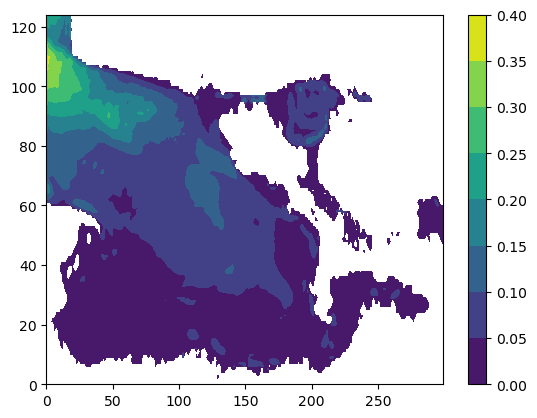

In [29]:
vel = np.sqrt(ocn.SSU[:, :, :-1].values**2 + ocn.SSV[:, :-1].values**2)

plt.figure()
plt.contourf(ocn.speed[-1])
plt.colorbar(label='Sea Surface Speed (m/s)')
plt.show()

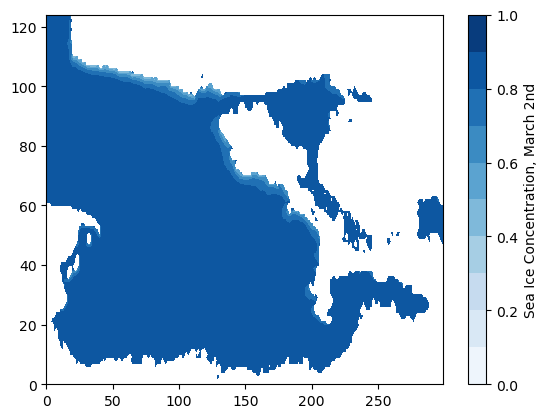

In [40]:
plt.figure()
plt.contourf(ice["aice_d"][0], cmap="Blues", levels=np.linspace(0, 1, 11))
plt.colorbar(label='Sea Ice Concentration, March 2nd')
plt.show()

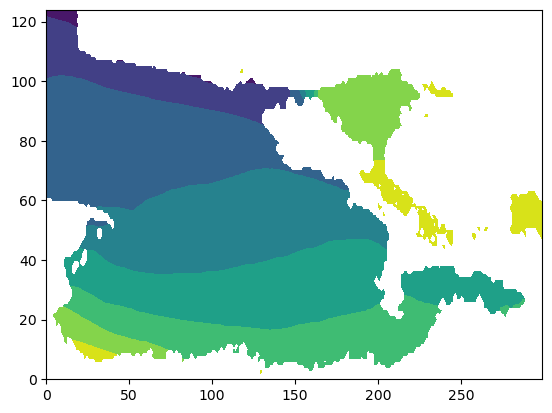

In [24]:
plt.figure()
plt.contourf(ocn.zos[0])
plt.show()

In [4]:
wave = ice["wave_sig_ht_d"].where(ice["wave_sig_ht_d"] < WAVE_MAX)
n_bad = int((ice["wave_sig_ht_d"] >= WAVE_MAX).isel(time=0).sum())
print(f"masked artifact cells: {n_bad} (expected ~327, constant in time)")

fig, ax = plt.subplots(figsize=(11, 4.2), subplot_kw={"projection": PROJ},
                       constrained_layout=True)
basemap(ax, f"Significant wave height in ice — {str(ice.time.values[day])[:10]}")
pc = ax.pcolormesh(LON, LAT, wave.isel(time=day).values, cmap="magma",
                   shading="nearest", transform=XT)
ax.contour(LON, LAT, ice["aice_d"].isel(time=day).values, levels=[ICE_EDGE],
           colors="c", linewidths=1.4, transform=XT)
fig.colorbar(pc, ax=ax, label="wave_sig_ht (m)", shrink=0.85)
plt.show()

KeyError: "No variable named 'wave_sig_ht_d'. Variables on the dataset include ['time_bounds', 'VGRDi', 'VGRDs', 'VGRDb', 'VGRDa', ..., 'NLON', 'NLAT', 'ELON', 'ELAT', 'NCAT']"

## 4. What the floe size distribution actually is

Ice concentration says *how much* ice. The FSD says *how it is broken up*.

`afsd_d` has an extra dimension `nf` — 12 floe-size categories, smallest to largest. For each grid
cell it gives the fraction of ice area in each size class, so it is a histogram per cell.
`fsdrad_d` collapses that to a single representative floe radius, which is the easy thing to map.

Below: a map of representative radius, then the full distribution at two contrasting points — one
near the ice edge, one deep in the pack. Expect the edge to be shifted toward small floes.

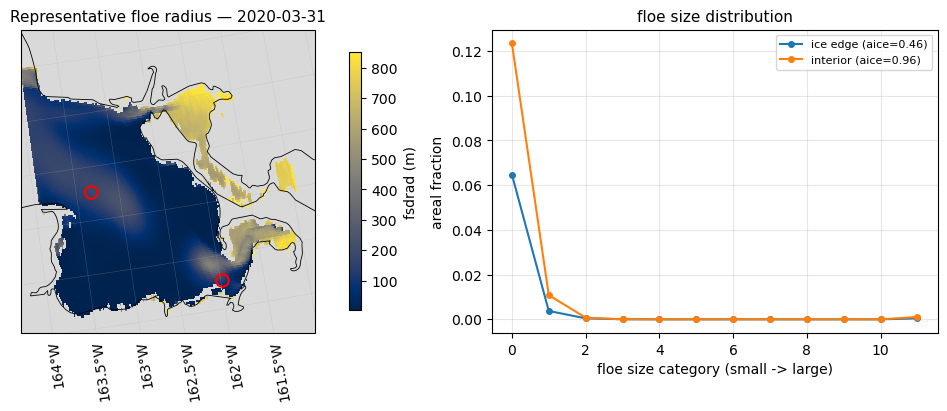

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.0), gridspec_kw={"width_ratios": [1.5, 1]}, constrained_layout=True)
axs[0].remove()
ax0 = fig.add_subplot(1, 2, 1, projection=PROJ)
basemap(ax0, f"Representative floe radius — {str(ice.time.values[day])[:10]}")

fsdrad = ice["fsdrad_d"].isel(time=day).where(ice["aice_d"].isel(time=day) > ICE_EDGE)
pc = ax0.pcolormesh(LON, LAT, fsdrad.values, cmap="cividis", shading="nearest", transform=XT)
fig.colorbar(pc, ax=ax0, label="fsdrad (m)", shrink=0.85)

# pick an edge cell and an interior cell from the same day
a = ice["aice_d"].isel(time=day).values
edge_mask = (a > ICE_EDGE) & (a < 0.5)
deep_mask = a > 0.95
jj, ii = np.where(edge_mask)
je, ie = (jj[len(jj)//2], ii[len(ii)//2]) if len(jj) else (0, 0)
jj, ii = np.where(deep_mask)
jd, idp = (jj[len(jj)//2], ii[len(ii)//2]) if len(jj) else (0, 0)

for (j, i), lab in [((je, ie), f"ice edge (aice={a[je, ie]:.2f})"),
                    ((jd, idp), f"interior (aice={a[jd, idp]:.2f})")]:
    axs[1].plot(np.arange(ice.sizes["nf"]), ice["afsd_d"].isel(time=day, nj=j, ni=i).values,
                marker="o", ms=4, label=lab)
    ax0.plot(LON[j, i], LAT[j, i], "o", mfc="none", mec="r", ms=9, mew=1.6, transform=XT)

axs[1].set_xlabel("floe size category (small -> large)")
axs[1].set_ylabel("areal fraction")
axs[1].set_title("floe size distribution", fontsize=11)
axs[1].legend(fontsize=8)
axs[1].grid(alpha=0.3)
plt.show()

## 5. Which process is reshaping the floes?

This is the most diagnostic view. CICE reports the FSD tendency split by process, and they form a
budget:

| term | process |
|---|---|
| `dafsd_wave_d` | **wave fracturing** — the wave-to-ice coupling |
| `dafsd_weld_d` | welding: floes freezing back together in calm conditions |
| `dafsd_newi_d` | new ice formation |
| `dafsd_latg_d` | lateral growth |
| `dafsd_latm_d` | lateral melt |

Wave fracturing has a characteristic signature: **negative at large floe sizes, positive at small
ones** — area being moved down the size spectrum as big floes shatter. That sign pattern, not the
magnitude, is the thing to recognise, and it is clearly visible in the left panel below.

The right panel puts fracturing activity next to peak wave height. Over only seven winter days
these do **not** track each other cleanly — do not read a correlation into it. Fracturing depends on
the wave *spectrum* reaching floes of a breakable size, not on peak height alone, and a week is far
too short a sample. This panel becomes meaningful over the 12-month run.

Only `dafsd_wave` is on the daily stream here; the others default to monthly. Add them to
`user_nl_cice` as `'mdxxx'` if you want the full budget daily.

ValueError: x and y must have same first dimension, but have shapes (31,) and (1,)

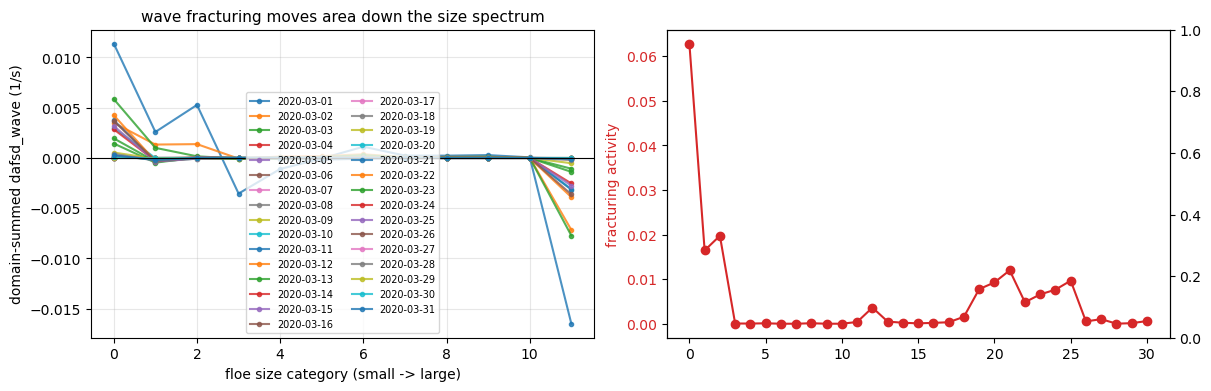

In [9]:
dw = ice["dafsd_wave_d"]
# domain-summed tendency per floe-size category, per day
prof = dw.sum(dim=("nj", "ni")).compute()

fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)

for t in range(NDAYS):
    axs[0].plot(np.arange(ice.sizes["nf"]), prof.isel(time=t).values,
                marker="o", ms=3, alpha=0.8, label=str(ice.time.values[t])[:10])
axs[0].axhline(0, color="k", lw=0.8)
axs[0].set_xlabel("floe size category (small -> large)")
axs[0].set_ylabel("domain-summed dafsd_wave (1/s)")
axs[0].set_title("wave fracturing moves area down the size spectrum", fontsize=11)
axs[0].legend(fontsize=7, ncol=2)
axs[0].grid(alpha=0.3)

# how active is fracturing, day by day, vs how big the waves are
frac = np.abs(dw).sum(dim=("nf", "nj", "ni")).compute()
# wmax = wave.max(dim=("nj", "ni")).compute()
ax2 = axs[1]
ax2.plot(DAYS, frac.values, "o-", color="tab:red", label="|dafsd_wave| (domain sum)")
ax2.set_ylabel("fracturing activity", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax3 = ax2.twinx()
ax3.plot(DAYS, 20, "s--", color="tab:blue", label="max wave_sig_ht")  # wmax.values
ax3.set_ylabel("max wave height (m)", color="tab:blue")
ax3.tick_params(axis="y", labelcolor="tab:blue")
ax2.set_title("fracturing activity vs wave height", fontsize=11)
ax2.grid(alpha=0.3)
datelabels(ax2)
plt.show()

## 6. Domain-integrated time series

The summary numbers an oceanographer will want: how much ice there is, how thick, how broken up,
and how energetic the waves are. Over a week these barely move; over a year they show the full
advance and retreat.

`ice area` is concentration times cell area summed — the physically meaningful quantity, as opposed
to *extent* (area of cells exceeding 15%), which is what satellite products usually report.

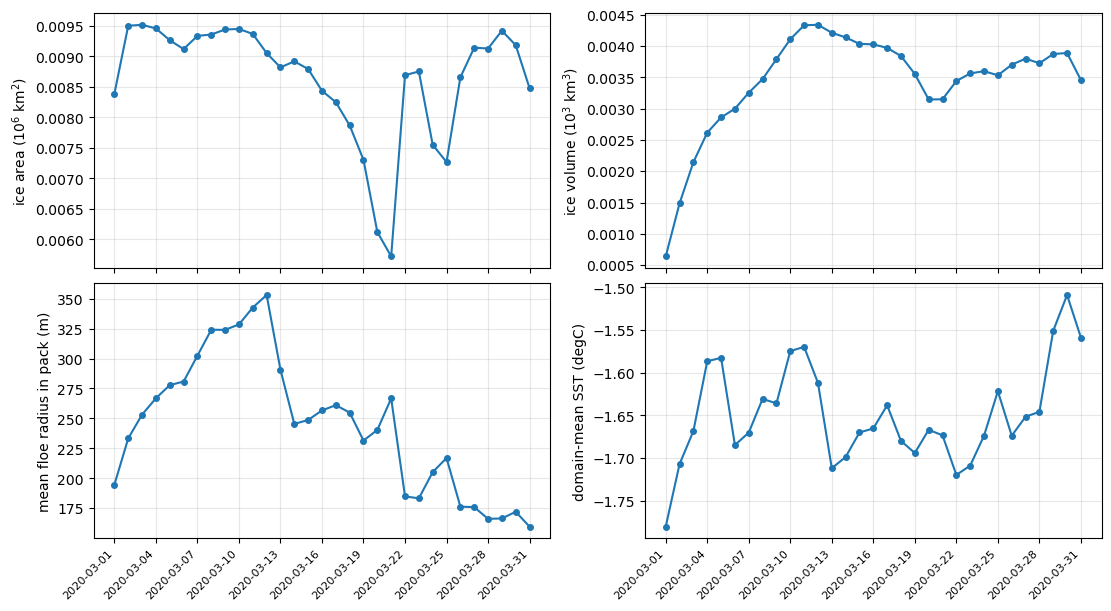

In [10]:
tarea = ice["tarea"].isel(time=0) if "time" in ice["tarea"].dims else ice["tarea"]

area = (ice["aice_d"] * tarea).sum(dim=("nj", "ni")).compute() / 1e12      # 10^6 km^2
vol  = (ice["hi_d"] * ice["aice_d"] * tarea).sum(dim=("nj", "ni")).compute() / 1e12  # 10^3 km^3
rad  = ice["fsdrad_d"].where(ice["aice_d"] > ICE_EDGE).mean(dim=("nj", "ni")).compute()
sst  = ocn["tos"].mean(dim=("yh", "xh")).compute()

fig, axs = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True, sharex=True)
for ax, y, lab in [(axs[0, 0], area, "ice area (10$^6$ km$^2$)"),
                   (axs[0, 1], vol,  "ice volume (10$^3$ km$^3$)"),
                   (axs[1, 0], rad,  "mean floe radius in pack (m)"),
                   (axs[1, 1], sst,  "domain-mean SST (degC)")]:
    ax.plot(DAYS[:y.sizes["time"]], y.values, "o-", ms=4)
    ax.set_ylabel(lab); ax.grid(alpha=0.3)
for ax in axs[1, :]:
    datelabels(ax)
plt.show()

## What to take away

- **Ice and SST are one system.** Ice forms where the ocean is at freezing; the ice edge and the
  -1.8 C isotherm track each other.
- **The FSD is the ice cover's grain size.** Two cells with identical concentration can melt at very
  different rates depending on how broken up they are, because melt happens at floe edges.
- **`dafsd_wave` is the coupling term to watch.** It is the only place in this model where the wave
  field changes the ice, and its negative-at-large / positive-at-small signature is the fingerprint
  of fracturing.
- **Remember what is missing.** No wave forcing at the boundaries means no remotely generated swell,
  which is the dominant ice-breaking agent in the real Bering Sea. Treat the wave-ice coupling here
  as a demonstration of mechanism, not a quantitative result.

### Next
A 12-month version of this case is being set up, which will make the animation in section 2 show a
full ice advance and retreat, and turn section 6 into a real seasonal cycle.